# Human Immune Health Atlas: sample representation benchmark

Blood immune single-cell data from the Dynamics of Immune Health and Age study (Nature 2025, [PMID 41162704](https://pubmed.ncbi.nlm.nih.gov/41162704/)). Donors vary in age and CMV status; cells are annotated with Allen Institute AIFI labels at several resolutions. 

Ideas here are based on ideas from the R package SETA https://github.com/CellDiscoveryNetwork/SETA.

Download `human_immune_health_atlas_full.h5ad` from the Immune Health Atlas catalog:
https://apps.allenimmunology.org/aifi/resources/imm-health-atlas/downloads/scrna/

Direct link to the full object (on the order of 40 GB) - clicking starts download!:
https://allenimmunology.org/public/publication/download/84792154-cdfb-42d0-8e42-39e210e980b4/filesets/568ad40c-516a-4646-9426-bdcd7029c1f5/human_immune_health_atlas_full.h5ad

Notebook is also based on https://carmonalab.github.io/scECODA_demo/Case_Study_1.html

## Compositions

Because this dataset is very large, we benchmark methods that are highly efficient. Compositions are perfect for rapid exploratory sample level analysis. We implemented CLR in `CellGroupComposition(apply_clr=True)` to build per-sample cell type proportions and apply a centered log-ratio (CLR). The other methods in the benchmark use the same label column but aggregate cells in different ways.


## Install patpy


In [1]:
# !pip install git+https://github.com/lueckenlab/patpy.git@main
# !pip install -q pilotpy


## Import packages


In [1]:
import warnings

import matplotlib.cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.collections import LineCollection
from matplotlib.patches import Ellipse
from matplotlib.colors import LinearSegmentedColormap
from plottable import ColumnDefinition, Table
from plottable.cmap import normed_cmap
from plottable.plots import bar
from scipy import stats
from sklearn.decomposition import PCA

import patpy

warnings.filterwarnings("ignore", category=UserWarning)


## Read the data

Set `ADATA_PATH` to your local `human_immune_health_atlas_full.h5ad`. The object should have `obsm['X_pca']` (used by pseudobulk-style methods).


In [2]:
ADATA_PATH = "/Users/kylekimler/Projects/patient-maps-playground/data/human_immune_health_atlas_full.h5ad"


In [3]:
adata = sc.read_h5ad(ADATA_PATH)
adata


AnnData object with n_obs by n_vars = 1821725 by 1236
    obs: 'cohort.cohortGuid', 'sample.sampleKitGuid', 'specimen.specimenGuid', 'pipeline.fileGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.birthYear', 'subject.ageAtFirstDraw', 'subject.ageGroup', 'subject.race', 'subject.ethnicity', 'subject.cmv', 'subject.bmi', 'sample.visitName', 'sample.drawYear', 'sample.subjectAgeAtDraw', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'barcodes', 'original_barcodes', 'cell_name', 'n_reads', 'n_umis', 'n_genes', 'total_counts_mito', 'pct_counts_mito', 'doublet_score', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3'
    var: 'mito', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'AIFI_L1_colors', 'AIFI_L2_colors', 'AIFI_L3_colors', 'celltypist.low_colors', 'hvg', 'keep_colors', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'seura

## Benchmark

For each AIFI resolution (L1–L3) and each method, including **PILOT** (Earth Mover's distances via `pilotpy`)—build sample distances and score them with KNN. Biological **relevant** targets and **technical** batch proxies use the same normalization as `knn_prediction_score` (technical scores inverted; Spearman scores taken in absolute value). Results are summarized in the **plottable `Table()`** (see `representation_methods_example.ipynb`).

This loop reuses the same `adata`; if you hit odd state, restart from a fresh `read_h5ad`. **PILOT** can be slow on the full atlas; reduce cells or samples if needed.


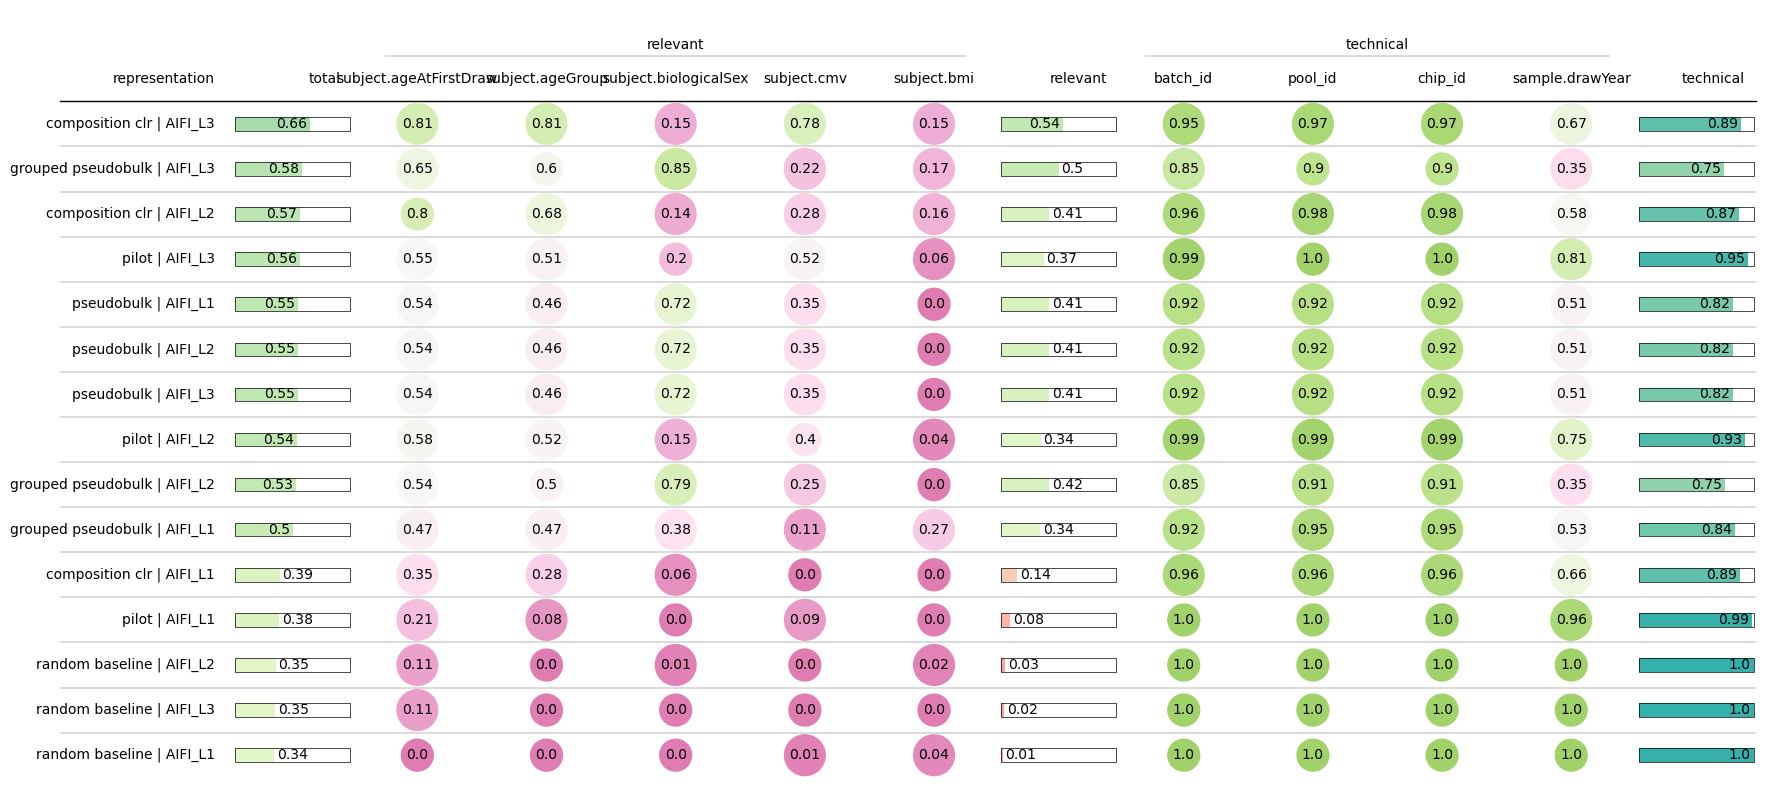

In [4]:
SAMPLE_KEY = "sample.sampleKitGuid"
LABEL_RESOLUTIONS = ["AIFI_L1", "AIFI_L2", "AIFI_L3"]
# PILOT expects a per-cell status column
PILOT_SAMPLE_STATE_COL = "subject.cmv"
# Columns used only for UMAP coloring below
AGE_COL = "subject.ageAtFirstDraw"
CMV_COL = "subject.cmv"
RNG = 67
N_NEIGHBORS = 7


# KNN tasks per covariate; "relevant" = biological, "technical" = batch / processing
BENCHMARK_SCHEMA = {
    "relevant": {
        "subject.ageAtFirstDraw": "regression",
        "subject.ageGroup": "classification",
        "subject.biologicalSex": "classification",
        "subject.cmv": "classification",
        "subject.bmi": "regression",
    },
    "technical": {
        "batch_id": "classification",
        "pool_id": "classification",
        "chip_id": "classification",
        "sample.drawYear": "regression",
    },
}

REQ_OBS = (
    {SAMPLE_KEY, CMV_COL, AGE_COL, *LABEL_RESOLUTIONS}
    | {c for bucket in BENCHMARK_SCHEMA.values() for c in bucket}
)

for col in REQ_OBS:
    assert col in adata.obs, col
assert "X_pca" in adata.obsm, "need X_pca in obsm for pseudobulk methods"


def build_method(method: str, label_key: str):
    if method == "composition_clr":
        return patpy.tl.CellGroupComposition(SAMPLE_KEY, label_key, apply_clr=True, seed=RNG)
    if method == "pseudobulk":
        return patpy.tl.Pseudobulk(SAMPLE_KEY, label_key, layer="X_pca", seed=RNG)
    if method == "grouped_pseudobulk":
        return patpy.tl.GroupedPseudobulk(SAMPLE_KEY, label_key, layer="X_pca", seed=RNG)
    if method == "random_baseline":
        return patpy.tl.RandomVector(SAMPLE_KEY, label_key, latent_dim=32, seed=RNG)
    if method == "pilot":
        return patpy.tl.PILOT(
            SAMPLE_KEY,
            label_key,
            sample_state_col=PILOT_SAMPLE_STATE_COL,
            layer="X_pca",
            seed=RNG,
        )
    raise ValueError(method)


METHOD_ORDER = ["composition_clr", "pseudobulk", "grouped_pseudobulk", "pilot", "random_baseline"]

rows: list[dict] = []
for label_key in LABEL_RESOLUTIONS:
    for method in METHOD_ORDER:
        m = build_method(method, label_key)
        m.prepare_anndata(adata)
        force = method.startswith("composition") or method == "pilot"
        m.calculate_distance_matrix(force=force)
        for covariate_type, cov_map in BENCHMARK_SCHEMA.items():
            for cov_col, task in cov_map.items():
                out = m.evaluate_representation(
                    cov_col, method="knn", n_neighbors=N_NEIGHBORS, task=task
                )
                rows.append(
                    {
                        "label_key": label_key,
                        "method": method,
                        "covariate": cov_col,
                        "covariate_type": covariate_type,
                        "task": task,
                        "score": out["score"],
                        "metric": out["metric"],
                    }
                )

benchmark_long = pd.DataFrame(rows)


def _plot_score(row: pd.Series) -> float:
    s = float(row["score"])
    if row["covariate_type"] == "technical":
        s = 1.0 - s
    if row["metric"] == "spearman_r":
        s = abs(s)
    return s


benchmark_long["plot_score"] = benchmark_long.apply(_plot_score, axis=1)

bio = benchmark_long[benchmark_long["covariate_type"] == "relevant"]
tech = benchmark_long[benchmark_long["covariate_type"] == "technical"]
summary = (
    bio.groupby(["label_key", "method"], as_index=False)["plot_score"]
    .mean()
    .rename(columns={"plot_score": "bio_mean"})
    .merge(
        tech.groupby(["label_key", "method"], as_index=False)["plot_score"]
        .mean()
        .rename(columns={"plot_score": "tech_mean"}),
        on=["label_key", "method"],
        how="outer",
    )
)
summary["mean_score"] = (summary["bio_mean"] + summary["tech_mean"]) / 2.0
results = summary.sort_values("mean_score", ascending=False).reset_index(drop=True)

knn_results_wide = benchmark_long.pivot_table(
    index=["method", "label_key"],
    columns="covariate",
    values="plot_score",
    aggfunc="first",
)

plot_df = knn_results_wide.reset_index()
plot_df["representation"] = plot_df["method"].str.replace("_", " ") + " | " + plot_df["label_key"]
plot_df = plot_df.drop(columns=["method", "label_key"]).set_index("representation")

for covariate_type, cov_map in BENCHMARK_SCHEMA.items():
    tcols = list(cov_map.keys())
    plot_df[covariate_type] = plot_df[tcols].mean(axis=1)

clin_weight = 2 / 3
plot_df["total"] = clin_weight * plot_df["relevant"] + (1 - clin_weight) * plot_df["technical"]

cols_order = ["total"]
for covariate_type in BENCHMARK_SCHEMA:
    cols_order.extend(list(BENCHMARK_SCHEMA[covariate_type].keys()))
    cols_order.append(covariate_type)

cmap = LinearSegmentedColormap.from_list(
    name="bugw", colors=["#FF9693", "#f2fbd2", "#c9ecb4", "#93d3ab", "#35b0ab"], N=256
)

col_defs: list = []
col_defs.append(
    ColumnDefinition(
        "total",
        width=0.7,
        plot_fn=bar,
        plot_kw={
            "cmap": cmap,
            "plot_bg_bar": True,
            "annotate": True,
            "height": 0.5,
            "lw": 0.5,
            "formatter": lambda x: round(x, 2),
        },
    )
)

for covariate_type in BENCHMARK_SCHEMA:
    type_cols = list(BENCHMARK_SCHEMA[covariate_type].keys())
    for col in type_cols:
        col_defs.append(
            ColumnDefinition(
                name=col,
                width=0.75,
                formatter=lambda x: round(x, 2),
                textprops={"ha": "center", "bbox": {"boxstyle": "circle", "pad": 0.35}},
                cmap=normed_cmap(benchmark_long["plot_score"], cmap=matplotlib.cm.PiYG, num_stds=2.5),
                group=covariate_type,
            )
        )
    col_defs.append(
        ColumnDefinition(
            covariate_type,
            width=0.7,
            plot_fn=bar,
            plot_kw={
                "cmap": cmap,
                "plot_bg_bar": True,
                "annotate": True,
                "height": 0.5,
                "lw": 0.5,
                "formatter": lambda x: round(x, 2),
            },
        )
    )

fig, ax = plt.subplots(figsize=(22, 10))
Table(
    plot_df[cols_order].sort_values("total", ascending=False),
    column_definitions=tuple(col_defs),
    ax=ax,
)
plt.show()


## The highest scoring method, CLR is highest on the highest-resolution labels (L3)

### In compositional analysis of ecological and microbiome data, CLR is compared with a global coherence metric, PERMANOVA. 

PERMANOVA can be useful over KNN in two situations: 
1. PERMANOVA provides a p-value metric through its permutational statistical test. 
2. PERMANOVA provides a *global* coherence metric (often plotted with 95% confidence ellipses around groups on embeddings), while the KNN better tracks local coherence in neighborhoods.

To compare these two metrics, we plot PERMANOVA with ellipses next to neighborhoods with the KNN metric.

**Left:** PCA of per-sample CLR compositions at **AIFI_L3**; **95%** bivariate normal confidence **ellipses** per **CMV** level (ordination ellipse style). An annotation box summarizes **PERMANOVA** (pseudo-F and permutation **p-value**) on the **same** Euclidean distance matrix used for CLR in patpy.

**Right:** Line segments connect each sample to its **k** nearest neighbors **in the full sample distance matrix**. An annotation box gives the **KNN** benchmark result for CMV (**k** matches `N_NEIGHBORS` above).


Ordination uses benchmark top CLR label: AIFI_L3 (mean_score=0.7149)


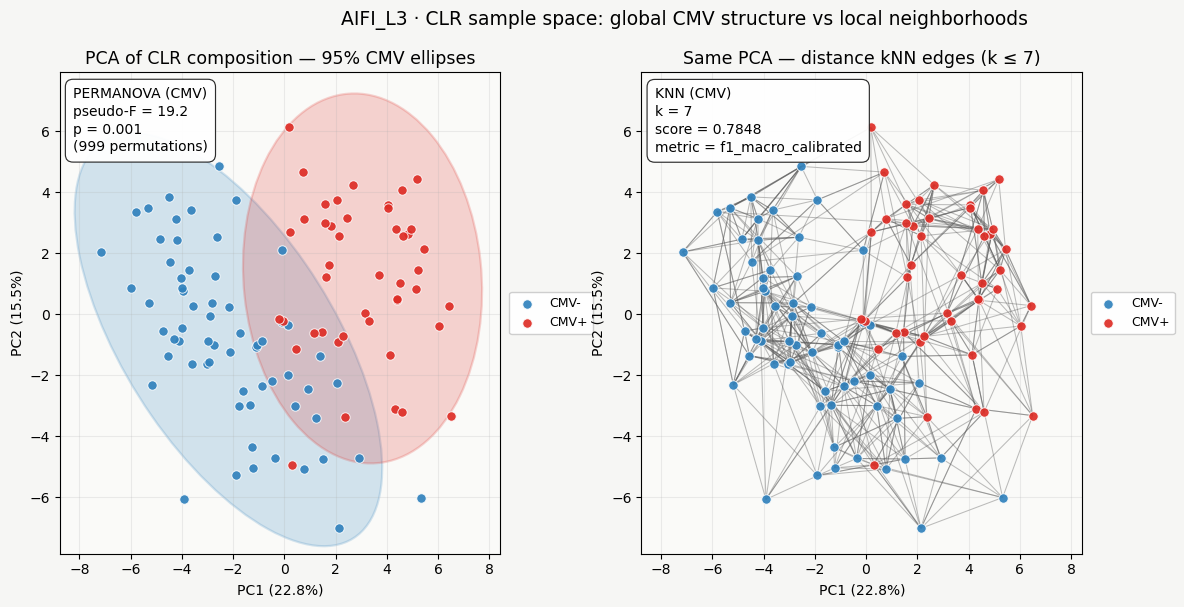

In [8]:
ELLIPSE_CHI2 = stats.chi2.ppf(0.95, 2)
PERMANOVA_PERMUTATIONS = 999
N_EDGE = int(min(N_NEIGHBORS, 12))

_clr_top = results[results["method"] == "composition_clr"].sort_values("mean_score", ascending=False)
ORD_LABEL = str(_clr_top.iloc[0]["label_key"])
print(
    f"Ordination uses benchmark top CLR label: {ORD_LABEL} "
    f"(mean_score={_clr_top.iloc[0]['mean_score']:.4f})"
)


def _cmv_display(x) -> str:
    s = str(x).strip().upper()
    if s in ("POSITIVE", "POS", "TRUE", "T", "1", "CMV+") or "POS" in s:
        return "CMV+"
    if s in ("NEGATIVE", "NEG", "FALSE", "F", "0", "CMV-") or "NEG" in s:
        return "CMV-"
    return str(x)


m_ord = patpy.tl.CellGroupComposition(SAMPLE_KEY, ORD_LABEL, apply_clr=True, seed=RNG)
m_ord.prepare_anndata(adata)
D_ord = np.asarray(m_ord.calculate_distance_matrix(force=True), dtype=float).copy()
X_ord = np.asarray(m_ord.sample_representation, dtype=float)
samples_ord = list(m_ord.sample_representation.index)
sample_table = adata.obs.drop_duplicates(subset=[SAMPLE_KEY], keep="first").set_index(SAMPLE_KEY)

cmv_ord = sample_table.loc[samples_ord, CMV_COL].map(_cmv_display)

pca_ord = PCA(n_components=2, random_state=RNG)
XY_ord = pca_ord.fit_transform(X_ord)

perm_ord = m_ord.evaluate_representation(
    CMV_COL, method="permanova", permutations=PERMANOVA_PERMUTATIONS
)
knn_ord = m_ord.evaluate_representation(
    CMV_COL, method="knn", n_neighbors=N_NEIGHBORS, task="classification"
)


def _ellipse_mu_wh_theta(xy: np.ndarray):
    if xy.shape[0] < 3:
        return None
    cov = np.cov(xy.T)
    det = np.linalg.det(cov)
    if det < 1e-14:
        return None
    mu = xy.mean(axis=0)
    vals, vecs = np.linalg.eigh(cov)
    order = np.argsort(vals)[::-1]
    vals = np.maximum(vals[order], 1e-12)
    vecs = vecs[:, order]
    theta = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    w = 2 * np.sqrt(ELLIPSE_CHI2 * vals[0])
    h = 2 * np.sqrt(ELLIPSE_CHI2 * vals[1])
    return mu, w, h, theta


D_nn = D_ord.copy()
np.fill_diagonal(D_nn, np.inf)
n_s = D_nn.shape[0]
edge_pairs = []
if n_s > 1:
    k_take = min(N_EDGE, n_s - 1)
    for i in range(n_s):
        part = np.argpartition(D_nn[i], k_take - 1)[:k_take]
        nn = part[part != i]
        if len(nn) == 0:
            continue
        nn = nn[np.argsort(D_nn[i, nn])]
        for j in nn[:N_EDGE]:
            edge_pairs.append((i, int(j)))

segments = [[XY_ord[i], XY_ord[j]] for i, j in edge_pairs]
levels = []
for lab in ("CMV-", "CMV+"):
    if (cmv_ord == lab).any():
        levels.append(lab)
for u in sorted(cmv_ord.unique(), key=str):
    if u not in levels:
        levels.append(u)
cmv_colors = {"CMV-": "#3182bd", "CMV+": "#de2d26"}
_q = np.linspace(0.15, 0.85, max(len(levels), 1))
color_cmv = {lev: cmv_colors.get(lev, plt.cm.Spectral(_q[i])) for i, lev in enumerate(levels)}

fig, (ax_e, ax_g) = plt.subplots(
    1,
    2,
    figsize=(20.5, 6.55),
    facecolor="#f6f6f4",
)
fig.subplots_adjust(wspace=0.62, left=0.10, right=0.58, top=0.84)
for ax in (ax_e, ax_g):
    ax.set_facecolor("#fafaf8")

for lev in levels:
    sel = (cmv_ord == lev).to_numpy()
    pts = XY_ord[sel]
    col = color_cmv[lev]
    ell = _ellipse_mu_wh_theta(pts)
    if ell is not None:
        mu, w_r, h_r, th = ell
        ax_e.add_patch(
            Ellipse(
                xy=mu,
                width=w_r,
                height=h_r,
                angle=th,
                facecolor=col,
                edgecolor=col,
                lw=1.6,
                alpha=0.2,
                zorder=1,
            )
        )
    ax_e.scatter(
        pts[:, 0],
        pts[:, 1],
        s=46,
        color=col,
        alpha=0.92,
        edgecolors="none",
        label=lev,
        zorder=3,
    )

perm_lines = (
    "PERMANOVA (CMV)"
    + chr(10)
    + f"pseudo-F = {perm_ord['score']:.4g}"
    + chr(10)
    + f"p = {perm_ord['p_value']:.4g}"
    + chr(10)
    + f"({PERMANOVA_PERMUTATIONS} permutations)"
)
ax_e.text(
    0.03,
    0.97,
    perm_lines,
    transform=ax_e.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    linespacing=1.35,
    bbox=dict(boxstyle="round,pad=0.55", facecolor="white", edgecolor="#222", alpha=0.95, linewidth=0.85),
)
ax_e.set_xlabel(f"PC1 ({pca_ord.explained_variance_ratio_[0] * 100:.1f}%)")
ax_e.set_ylabel(f"PC2 ({pca_ord.explained_variance_ratio_[1] * 100:.1f}%)")
ax_e.set_title("PCA of CLR composition: 95% CMV ellipses", fontsize=12.5)
ax_e.legend(
    framealpha=0.94,
    fontsize=9,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0,
)
ax_e.grid(True, alpha=0.22)

if segments:
    ax_g.add_collection(
        LineCollection(segments, colors="#5c5c5c", alpha=0.4, linewidths=0.75, zorder=0)
    )
for lev in levels:
    sel = (cmv_ord == lev).to_numpy()
    pts = XY_ord[sel]
    col = color_cmv[lev]
    ax_g.scatter(
        pts[:, 0],
        pts[:, 1],
        s=46,
        color=col,
        alpha=0.92,
        edgecolors="none",
        label=lev,
        zorder=3,
    )

knn_lines = (
    "KNN (CMV)"
    + chr(10)
    + f"k = {N_NEIGHBORS}"
    + chr(10)
    + f"score = {knn_ord['score']:.4f}"
    + chr(10)
    + f"metric = {knn_ord['metric']}"
)
ax_g.text(
    0.03,
    0.97,
    knn_lines,
    transform=ax_g.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    linespacing=1.35,
    bbox=dict(boxstyle="round,pad=0.55", facecolor="white", edgecolor="#222", alpha=0.95, linewidth=0.85),
)
ax_g.set_xlabel(f"PC1 ({pca_ord.explained_variance_ratio_[0] * 100:.1f}%)")
ax_g.set_ylabel(f"PC2 ({pca_ord.explained_variance_ratio_[1] * 100:.1f}%)")
ax_g.set_title(f"Same PCA, kNN edges (k <= {N_EDGE})", fontsize=12.5)
ax_g.legend(
    framealpha=0.94,
    fontsize=9,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0,
)
ax_g.grid(True, alpha=0.22)
ax_g.set_xlim(ax_e.get_xlim())
ax_g.set_ylim(ax_e.get_ylim())

fig.suptitle(
    f"{ORD_LABEL}, CLR sample space: global CMV structure vs local neighborhoods",
    fontsize=13.5,
    y=0.995,
)
plt.show()


## Using compositional PCA to analyze scRNAseq patient groups

The CLR PCA winning the benchmark captures both age group and CMV status. 

Scatter plots by colour for CMV (values mapped to CMV- and CMV+) and by age group show this separation. Since this unbiased PCA separates these groups, we can simply look at compositional loadings to understand differences between groups.

Bar plots show the top five negative and positive PC loadings. 

The heatmap that follows is mean CLR for CMV+ minus CMV- within each age group. There are only 3 children with CMV+. Additionally, some cell types might not be present within each group. If at least 1 sample contains a cell type we plot it for that group here. This way we can see how CMV affects the immune compartment across age groups. 


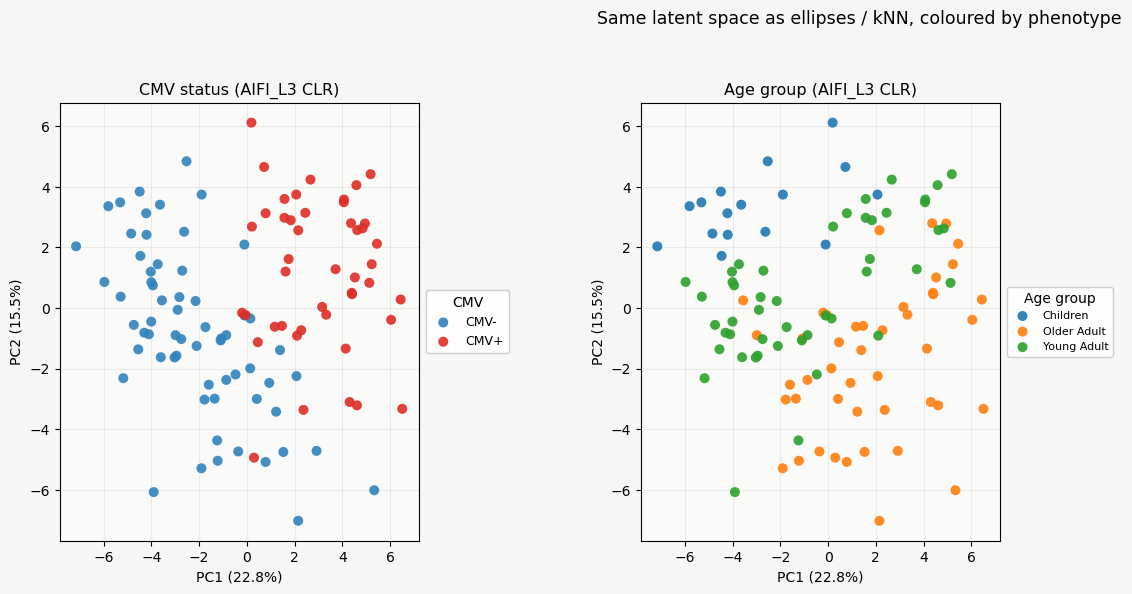

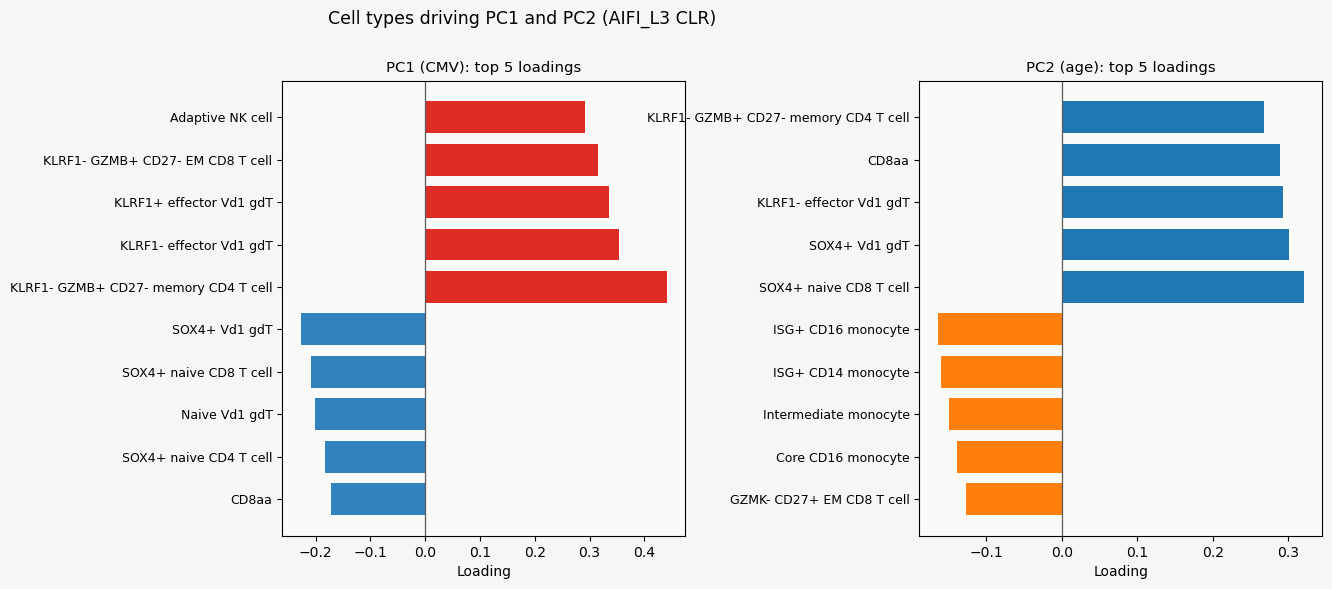

Samples per age group by CMV (mapped):
 CMV          CMV-  CMV+
age                    
Children       13     3
Older Adult    21    24
Young Adult    29    18
Heatmap: mean CLR diff (CMV+ - CMV-); Children uses min 1 donor per CMV arm.


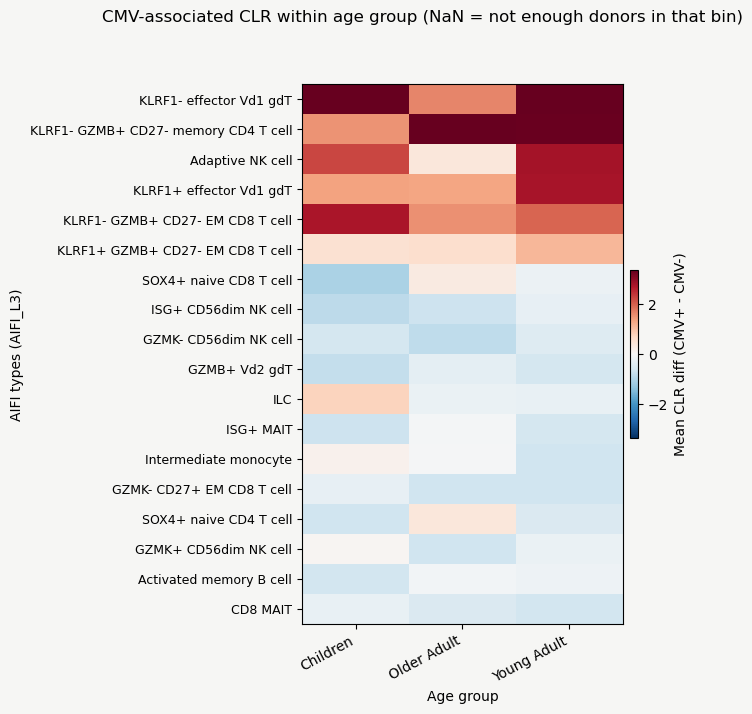

In [16]:
# Identical PCA as previous cell: XY_ord, pca_ord, X_ord, ORD_LABEL, samples_ord, cmv_ord, levels, color_cmv.
cell_types = np.asarray(m_ord.sample_representation.columns.astype(str))
age_ord = sample_table.loc[samples_ord, "subject.ageGroup"].astype(str)
age_levels = sorted(pd.unique(age_ord), key=str)
# Saturated categorical colors (tab10), visible on light backgrounds
_tab_colors = plt.cm.tab10(np.linspace(0, 0.9, 10))
age_palette = {lev: _tab_colors[i % 10] for i, lev in enumerate(age_levels)}
_load_child = next((a for a in age_levels if str(a) == "Children"), None)
_load_older = next((a for a in age_levels if "older" in str(a).lower()), None)
pc2_bar_neg = age_palette.get(_load_older, "#6A3D9A")
pc2_bar_pos = age_palette.get(_load_child, "#FF7F00")

# --- 1) Same coordinates as PERMANOVA / kNN: CMV and age ---
fig1, (ax_c, ax_a) = plt.subplots(1, 2, figsize=(20.0, 6.0), facecolor="#f6f6f4")
fig1.subplots_adjust(wspace=0.62, left=0.10, right=0.57, top=0.84)
ax_c.set_facecolor("#fafaf8")
ax_a.set_facecolor("#fafaf8")

for lev in levels:
    sel = (cmv_ord == lev).to_numpy()
    ax_c.scatter(
        XY_ord[sel, 0],
        XY_ord[sel, 1],
        s=52,
        c=[color_cmv[lev]],
        alpha=0.9,
        edgecolors="none",
        label=lev,
        zorder=3,
    )

ax_c.set_xlabel(f"PC1 ({pca_ord.explained_variance_ratio_[0] * 100:.1f}%)")
ax_c.set_ylabel(f"PC2 ({pca_ord.explained_variance_ratio_[1] * 100:.1f}%)")
ax_c.set_title(f"CMV status ({ORD_LABEL} CLR)", fontsize=11.5)
ax_c.grid(True, alpha=0.22)
ax_c.legend(
    title="CMV",
    fontsize=9,
    title_fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0,
    frameon=True,
    framealpha=0.95,
)

for ag in age_levels:
    sel = (age_ord == ag).to_numpy()
    ax_a.scatter(
        XY_ord[sel, 0],
        XY_ord[sel, 1],
        s=52,
        c=[age_palette[ag]],
        alpha=0.9,
        edgecolors="none",
        label=str(ag),
        zorder=3,
    )

ax_a.set_xlabel(f"PC1 ({pca_ord.explained_variance_ratio_[0] * 100:.1f}%)")
ax_a.set_ylabel(f"PC2 ({pca_ord.explained_variance_ratio_[1] * 100:.1f}%)")
ax_a.set_title(f"Age group ({ORD_LABEL} CLR)", fontsize=11.5)
ax_a.grid(True, alpha=0.22)
ax_a.legend(
    title="Age group",
    fontsize=8,
    title_fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0,
    frameon=True,
    framealpha=0.95,
)
xlim_shared = ax_c.get_xlim()
ylim_shared = ax_c.get_ylim()
ax_a.set_xlim(xlim_shared)
ax_a.set_ylim(ylim_shared)
fig1.suptitle("Same latent space as ellipses / kNN, coloured by phenotype", fontsize=12.5, y=0.995)
plt.show()

# --- 2) PC loadings: horizontal bars (same sklearn PCA), readable ---
TOP_K = 5
PC1_NEG, PC1_POS = cmv_colors["CMV-"], cmv_colors["CMV+"]


def _plot_pc_loadings(pc_idx: int, ax, *, neg_c: str, pos_c: str, title: str):
    comp = pca_ord.components_[pc_idx]
    order = np.argsort(comp)
    neg_ix = order[:TOP_K]
    pos_ix = order[-TOP_K:][::-1]
    sel = np.concatenate([neg_ix[::-1], pos_ix])
    y = np.arange(len(sel))
    vals = comp[sel]
    cols = [neg_c if v < 0 else pos_c for v in vals]
    ax.barh(y, vals, color=cols, height=0.75, edgecolor="none")
    ax.axvline(0, color="0.35", lw=0.9)
    ax.set_yticks(y)
    ax.set_yticklabels(cell_types[sel], fontsize=9)
    ax.set_xlabel("Loading")
    ax.set_title(title, fontsize=10.75)


fig2, axes_ld = plt.subplots(1, 2, figsize=(20.0, 6.15), facecolor="#f6f6f4")
fig2.subplots_adjust(wspace=0.58, left=0.38, right=0.90, top=0.88, bottom=0.14)
axes_ld[0].set_facecolor("#fafaf8")
axes_ld[1].set_facecolor("#fafaf8")
_plot_pc_loadings(
    0,
    axes_ld[0],
    neg_c=PC1_NEG,
    pos_c=PC1_POS,
    title="PC1 (CMV): top 5 loadings",
)
_plot_pc_loadings(
    1,
    axes_ld[1],
    neg_c=pc2_bar_neg,
    pos_c=pc2_bar_pos,
    title=(
        "PC2 (age): top 5 loadings"
    ),
)
fig2.suptitle(
    f"Cell types driving PC1 and PC2 ({ORD_LABEL} CLR)",
    fontsize=12.5,
    y=0.995,
)
plt.show()

# Mean CLR difference CMV+ minus CMV- within age group; include Children column when present
ageg_col = "subject.ageGroup"
age_series = sample_table.loc[samples_ord, ageg_col].astype(str).values
cmv_arr = cmv_ord.loc[samples_ord].values

if not ((cmv_arr == "CMV-").any() and (cmv_arr == "CMV+").any()):
    print("Need both CMV- and CMV+ after mapping for stratified heatmap.")
else:
    v_lo, v_hi = "CMV-", "CMV+"
    raw_ages = sorted(pd.unique(age_series), key=str)
    if "Children" in raw_ages:
        age_order = ["Children"] + [a for a in raw_ages if a != "Children"]
    else:
        age_order = list(raw_ages)

    col_names = []
    col_vectors = []

    for ag in age_order:
        sel = age_series == str(ag)
        relax = str(ag) == "Children"
        min_total = 4 if relax else 15
        min_each = 1 if relax else 5

        if sel.sum() < min_total:
            col_names.append(str(ag))
            col_vectors.append(np.full(len(cell_types), np.nan))
            continue

        cmv_s = cmv_arr[sel]
        X_sub = X_ord[sel]
        i_lo = cmv_s == v_lo
        i_hi = cmv_s == v_hi
        if i_lo.sum() < min_each or i_hi.sum() < min_each:
            col_names.append(str(ag))
            col_vectors.append(np.full(len(cell_types), np.nan))
            continue

        delta = X_sub[i_hi].mean(0) - X_sub[i_lo].mean(0)
        col_names.append(str(ag))
        col_vectors.append(np.ravel(delta))

    _x = pd.crosstab(pd.Series(age_series, name="age"), pd.Series(cmv_arr, name="CMV"), margins=False)
    print("Samples per age group by CMV (mapped):\n", _x.to_string())
    print(f"Heatmap: mean CLR diff ({v_hi} - {v_lo}); Children uses min 1 donor per CMV arm.")

    Dmat = np.column_stack(col_vectors)
    delta_df = pd.DataFrame(Dmat, index=cell_types, columns=col_names)
    top_ct = delta_df.abs().max(axis=1).nlargest(18).index
    vals = delta_df.loc[top_ct].values.astype(float)
    q = np.nanquantile(np.abs(vals), 0.98)
    q = float(q) if q > 0 else 1.0

    fig3, axh = plt.subplots(figsize=(max(6.0, 1.45 * len(col_names)), 8.3), facecolor="#f6f6f4")
    im = axh.imshow(vals, aspect="auto", cmap="RdBu_r", vmin=-q, vmax=q)
    axh.set_xticks(range(len(col_names)))
    axh.set_xticklabels(col_names, rotation=28, ha="right")
    axh.set_yticks(range(len(top_ct)))
    axh.set_yticklabels(top_ct, fontsize=9)
    axh.set_xlabel("Age group")
    axh.set_ylabel(f"AIFI types ({ORD_LABEL})")
    cb = fig3.colorbar(im, ax=axh, fraction=0.025, pad=0.02)
    cb.set_label(f"Mean CLR diff ({v_hi} - {v_lo})")
    fig3.suptitle(
        "CMV-associated CLR within age group (NaN = not enough donors in that bin)",
        fontsize=12,
        y=0.98,
    )
    fig3.subplots_adjust(left=0.30, right=0.86, top=0.89, bottom=0.24)
    plt.show()


## UMAP on distances for top runs

UMAPs can capture nonlinear relationships. For a fair comparison between PILOT and CLR, we plot and compare each method with important covariates with UMAPs below


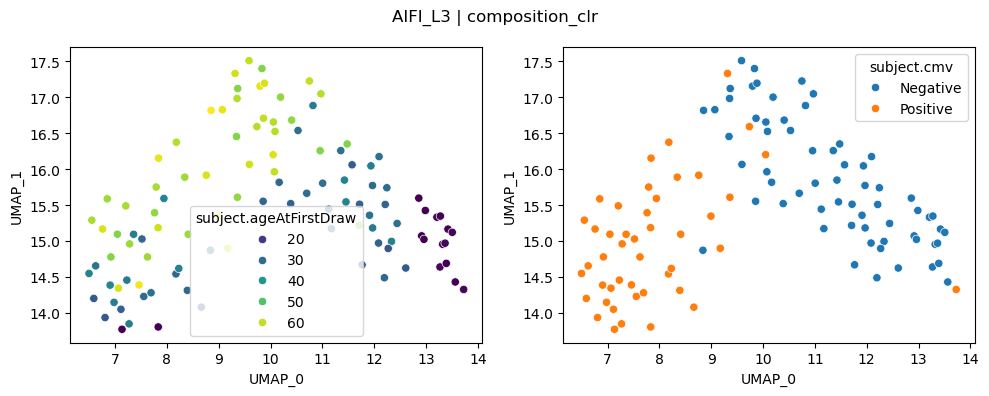

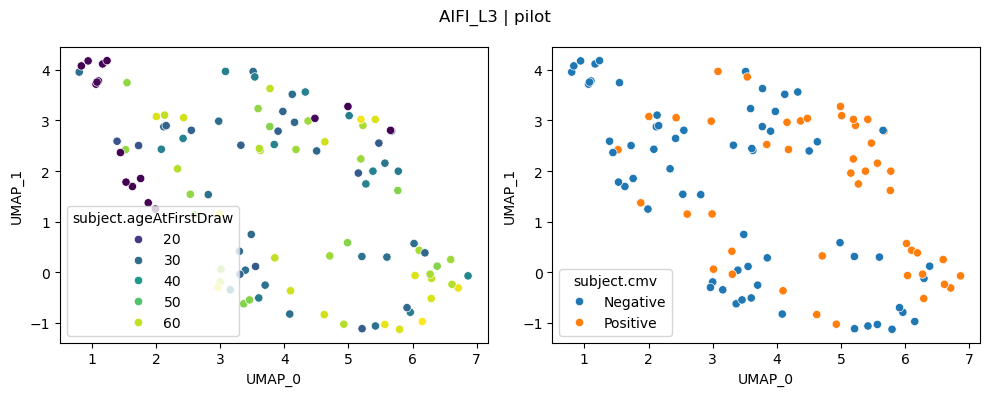

In [8]:
top2 = results.sort_values("mean_score", ascending=False).head(2)
for _, row in top2.iterrows():
    label_key = row["label_key"]
    method = row["method"]
    m = build_method(method, label_key)
    m.prepare_anndata(adata)
    m.calculate_distance_matrix(force=method.startswith("composition"))
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    m.plot_embedding(method="UMAP", metadata_cols=[AGE_COL, CMV_COL], axes=axes)
    fig.suptitle(f"{label_key} | {method}")
    plt.tight_layout()
